# **Database Monitoring Script - Cocaine Seizures (2025)**
#### InSight Crime - MAD Unit 

---------------------


## Setup

#### Version Control

The project is created within a single GitHub repository ([FelipeVillota/db-check](https://github.com/FelipeVillota/db-check-cocaine-seizures)). I keep the repository `private` with the possibility to give access to the online repo at any time. 

#### Environment

In [24]:
import os
import subprocess
import sys

# Subprocess Scripting Automation to manage and reproduce Python virtual environment and prepare packages

# Define environment name and path
venv_name = "venv-db-check"
venv_path = os.path.join(os.getcwd(), venv_name)

# 1. Create the virtual environment if it doesn't exist
if not os.path.exists(venv_path):
    # On Linux Mint, ensure python3-venv is installed
    try:
        subprocess.run([sys.executable, "-m", "venv", venv_path], check=True)
        print(f"✅ Created virtual environment: {venv_name}")
    except subprocess.CalledProcessError as e:
        sys.exit(1)
else:
    print(f"✅ Virtual environment '{venv_name}' already exists.")

# 2. Define the venv's python executable (Linux-specific)
venv_python = os.path.join(venv_path, "bin", "python")

# Safety check with more descriptive error
if not os.path.exists(venv_python):
    raise FileNotFoundError(
        f"Python executable not found at {venv_python}\n"
        "If you're on Linux Mint, ensure the virtual environment was created properly."
    )

# 3. Install and upgrade packages using the venv's Python, only if needed
packages = [
    "gspread", "pandas", "requests", "google-api-python-client",
    "oauth2client", "matplotlib", "seaborn", "missingno",
    "gspread-formatting", "ipykernel", "openpyxl"
]

# Get list of already installed packages
try:
    result = subprocess.run(
        [venv_python, "-m", "pip", "freeze"],
        capture_output=True, text=True, check=True
    )
    installed_packages = result.stdout.lower()
except subprocess.CalledProcessError:
    installed_packages = ""
    print("⚠️ No packages installed yet in virtual environment")

# Check if all required packages are already installed
missing = [pkg for pkg in packages if not any(pkg.lower() in line for line in installed_packages.splitlines())]

if missing:
    print(f"⚠️ Missing packages: {missing}")
    subprocess.run([venv_python, "-m", "pip", "install", "--upgrade", "pip"], check=True)
    subprocess.run([venv_python, "-m", "pip", "install"] + missing, check=True)
    print("✅ Installed missing packages into virtual environment")
else:
    print("✅ All required packages already installed — skipping installation.")

# 4. Register the venv as a Jupyter kernel
kernel_name = "db-check"
display_name = "Python (db-check)"

try:
    subprocess.run([
        venv_python, "-m", "ipykernel", "install", "--user",
        "--name", kernel_name,
        "--display-name", display_name
    ], check=True)
    print(f"✅ Registered Jupyter kernel: {display_name}")
except subprocess.CalledProcessError as e:
    print("Failed to register Jupyter kernel. On Linux Mint, you may need to install jupyter first:")
    print("Try running: sudo apt install jupyter-core")
    sys.exit(1)

# 5. Print the Python executable path being used
print("Python executable:", venv_python)

# 6. Freeze the current package list to requirements.txt
requirements_path = os.path.join(os.getcwd(), "requirements.txt")
with open(requirements_path, "w") as f:
    subprocess.run([venv_python, "-m", "pip", "freeze"], stdout=f, check=True)
print(f"✅ requirements.txt created at {requirements_path}")

✅ Virtual environment 'venv-db-check' already exists.
✅ All required packages already installed — skipping installation.
Installed kernelspec db-check in /home/lfvm/.local/share/jupyter/kernels/db-check
✅ Registered Jupyter kernel: Python (db-check)
Python executable: /home/lfvm/Desktop/codebaker/all_python/db-check/C17H21NO4/2025/venv-db-check/bin/python
✅ requirements.txt created at /home/lfvm/Desktop/codebaker/all_python/db-check/C17H21NO4/2025/requirements.txt


In [25]:
import os
from datetime import datetime

# Get current date
print("Current Date:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

# Count items, files, and directories
items = os.listdir()
files = [f for f in items if os.path.isfile(f)]
directories = [d for d in items if os.path.isdir(d)]

print(f"Total Items: {len(items)}")
print(f"Files: {len(files)}")
print(f"Directories: {len(directories)}")

# Get files sorted by modification time 
print("\nJust files (newest first):")
files_with_mtime = [(f, os.path.getmtime(f)) for f in items if os.path.isfile(f)]
sorted_files = sorted(files_with_mtime, key=lambda x: x[1], reverse=True)

for file, mtime in sorted_files:
    print(f"{datetime.fromtimestamp(mtime)} - {file}")

Current Date: 2025-08-19 13:08:32
Total Items: 6
Files: 3
Directories: 3

Just files (newest first):
2025-08-19 13:08:31.195016 - script.ipynb
2025-08-19 13:08:29.717020 - requirements.txt
2025-08-17 21:30:39.197024 - README.md


#### Libraries

In [26]:
import re
import requests
import pandas as pd
from datetime import datetime
from google.oauth2 import service_account
from googleapiclient.discovery import build
import gspread
from google.oauth2.service_account import Credentials
from gspread_formatting import format_cell_ranges, CellFormat, Color
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import openpyxl as px

### API

This creates a modular client (frontend) call that is able to extract the desired subset of data from the API server (backend); -and, make it easily reusable for future queries.


In [ ]:
# Path to your service account key file
SERVICE_ACCOUNT_FILE = '/home/lfvm/Desktop/codebaker/nyckelring/brelok/summer-sector-439022-v6-2eafffbbfb90.json' # Update with the actual path or team credentials file

# VERY IMPORTANT: Ensure the service account has access to the Google Sheet by sharing it with the service account email

# Original Google Sheet ID (latest version) 
ORIGINAL_SPREADSHEET_ID =  '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o'

# Define scopes for Google Sheets and Drive API
SCOPES = ['https://www.googleapis.com/auth/spreadsheets', 
          'https://www.googleapis.com/auth/drive']

In [28]:
# Authenticate and build both Sheets and Drive services
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
sheet_service = build('sheets', 'v4', credentials=creds)
drive_service = build('drive', 'v3', credentials=creds)

In [29]:
# Original spreadsheet
# Last modification: user and time. This information is related to the file itself, not to specific content (sheets, cells, rows)

from googleapiclient.discovery import build
from datetime import datetime
import pytz

def get_last_modifying_user(drive_service, file_id):
    try:
        # Get revisions (only the last one)
        revisions = drive_service.revisions().list(
            fileId=file_id,
            fields="revisions(modifiedTime,lastModifyingUser)"
        ).execute().get('revisions', [])
        
        if not revisions:
            return "No revisions found."
        
        last_revision = revisions[-1]  # Most recent revision
        user_info = last_revision.get('lastModifyingUser', {})
        email = user_info.get('emailAddress', 'Unknown')
        modified_time = last_revision.get('modifiedTime', 'Unknown')
        
        # Convert to readable datetime
        if modified_time != 'Unknown':
            dt = datetime.strptime(modified_time, "%Y-%m-%dT%H:%M:%S.%fZ")
            dt = dt.replace(tzinfo=pytz.UTC)
            modified_time = dt.strftime("%Y-%m-%d %H:%M:%S (UTC)")
        
        return {
            "user_email": email,
            "modified_time": modified_time
        }
    
    except Exception as e:
        return f"Error: {str(e)}"

# Usage
# First get the file name and sheet name
file_metadata = drive_service.files().get(fileId=ORIGINAL_SPREADSHEET_ID, fields='name').execute()
file_name = file_metadata.get('name', 'Unknown')

# Get sheet names
sheets = sheet_service.spreadsheets().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    fields='sheets(properties(title))'
).execute().get('sheets', [])

sheet_names = [sheet['properties']['title'] for sheet in sheets]

# Get last modifier info
last_modifier = get_last_modifying_user(drive_service, ORIGINAL_SPREADSHEET_ID)


print(
    f"📄 File name: {file_name}\n"
    f"📑 Sheet names: {', '.join(sheet_names)}\n"
    f"🔄 Last modified by: {last_modifier['user_email']}\n"
    f"⏰ Last modified at: {last_modifier['modified_time']}"
)

📄 File name: incautaciones cocaina 01-02
📑 Sheet names: Seizures, Guide, 2025, 2024, VRAEM, 2023, Primary Sources, origins, db-test
🔄 Last modified by: db-watch@summer-sector-439022-v6.iam.gserviceaccount.com
⏰ Last modified at: 2025-08-18 23:08:59 (UTC)


## Import & Data Sync

* Dataset A → raw truth (unformatted, growing, messy), new data appended here (by import, manual or automation).

* Dataset A_aligned → intermediate layer, schema-aligned.

* Dataset B → working copy and test scenario → the team works here for formatting, validations, and  corrections.

* Sync rules must handle:

    - New rows in A that should appear in B.

    - Updated rows in A that should update B (without overwriting B’s corrections).

    - Corrections in B that eventually need to be reconciled back to A.

In [44]:
# Function to duplicate an existing sheet and keep it hidden
def duplicate_sheet_hidden(sheet_service, spreadsheet_id, source_sheet_name, new_sheet_name):
    # First get the sheet ID of the source sheet
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id
    ).execute()
    
    source_sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == source_sheet_name:
            source_sheet_id = sheet['properties']['sheetId']
            break
    
    if source_sheet_id is None:
        raise ValueError(f"Sheet '{source_sheet_name}' not found")
    
    # Create a duplicate of the sheet
    batch_update_request = {
        "requests": [
            {
                "duplicateSheet": {
                    "sourceSheetId": source_sheet_id,
                    "insertSheetIndex": 8,  # Position where to insert the new sheet
                    "newSheetName": new_sheet_name
                }
            }
        ]
    }
    
    # Execute the batch update to duplicate the sheet
    response = sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=batch_update_request
    ).execute()
    
    # Get the ID of the newly created sheet
    new_sheet_id = response['replies'][0]['duplicateSheet']['properties']['sheetId']
    
    # Update the sheet properties to hide it
    hide_request = {
        "requests": [
            {
                "updateSheetProperties": {
                    "properties": {
                        "sheetId": new_sheet_id,
                        "hidden": True
                    },
                    "fields": "hidden"
                }
            }
        ]
    }
    
    # Execute the batch update to hide the sheet
    sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=hide_request
    ).execute()
    
    print(f"Duplicated sheet '{source_sheet_name}' to hidden sheet '{new_sheet_name}'")
    return response

# Use this function to duplicate and hide the sheet
duplicate_sheet_hidden(sheet_service, ORIGINAL_SPREADSHEET_ID, "2025", "aligned")

Duplicated sheet '2025' to hidden sheet 'aligned'


{'spreadsheetId': '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o',
 'replies': [{'duplicateSheet': {'properties': {'sheetId': 264057467,
     'title': 'aligned',
     'index': 8,
     'sheetType': 'GRID',
     'gridProperties': {'rowCount': 787,
      'columnCount': 49,
      'frozenRowCount': 1}}}}]}

In [46]:
# Read data from from two different sheets

def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"  # Add and adjust range if needed 
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()  # Return empty if no data
    return pd.DataFrame(values[1:], columns=values[0])  # Row 0 = headers

# Fetch data from '2025' and 'db-test' sheets

df_a_aligned = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
df_b = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")

print("\n=== Dataset A_aligned ===")
print(df_a_aligned.info())

print("=== Dataset B ===")
print(df_b.info())


=== Dataset A_aligned ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Type                             717 non-null    object
 1   Time unit                        717 non-null    object
 2   Date                             717 non-null    object
 3   Date 2                           717 non-null    object
 4   Year                             717 non-null    object
 5   Month                            717 non-null    object
 6   Day                              717 non-null    object
 7   Duration                         717 non-null    object
 8   Type Drugs                       717 non-null    object
 9   Quantity                         717 non-null    object
 10  Weight unit                      717 non-null    object
 11  seizure_kgs                      717 non-null    object
 12  Modus Ope

### Schema

#### Pre-process

In [47]:
# Handle Missing/Invalid Values. We want to keep this step as simple as possible, as we will be changing the data structure later.
 
df_a_aligned = df_A.replace('', pd.NA)  # Convert empty strings to NA
df_a_aligned = df_A.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


#### Column names

In [48]:
# Dictionary mapping old column names to new names
custom_column_names = {
    "Type": "event_type",
    "Time unit": "time_unit",
    "Date": "date_1",
    "Date 2": "date_2",
    "Year": "year",
    "Month": "month",
    "Day": "day",
    "Duration": "duration",
    "Type Drugs": "drug_type",
    "Quantity": "quantity",
    "Weight unit": "weight_unit",
    "seizure_kgs": "seizure_kg",
    "Modus Operandi/place of seizure": "modus_operandi/place_seizure",
    "Sub MO": "sub_modus_operandi",
    "Region": "region",
    "Country": "country",
    "Department/State": "department/state",
    "Municipality/Port": "municipality/port",
    "Origin country": "origin_country",
    "Origin Area": "origin_area",
    "Origin municipality": "origin_municipality",
    "Transit 1/Region": "transit_1_region",
    "Transit 1/country": "transit_1_country",
    "Transit 1/Department": "transit_1_department/state",
    "Transit 1/Municipality": "transit_1_municipality/port",
    "Transit 2/ region": "transit_2_region",
    "Transit 2/ country": "transit_2_country",
    "Transit 2/Department": "transit_2_department/state",
    "Transit 2/municipality/port": "transit_2_municipality/port",
    "Destition - Region": "destination_1_region",
    "Destition - Country": "destination_1_country",
    "Destition - department.state": "destination_1_department/state",
    "Destition - Municipality/Port": "destination_1_municipality/port",
    "Destition 2 - Country": "destination_2_country",
    "Destition 2 - Municipality/Port": "destination_2_municipality/port",
    "Description": "description",
    "Criminal group #1": "criminal_group_1",
    "Criminal group #2": "criminal_group_2",
    "Criminal group #3": "criminal_group_3",
    "Source link": "source_link",
    "Project interested": "project_interest"
}

# Apply renaming
df_a_aligned.rename(columns=custom_column_names, inplace=True)


In [49]:
# Get the current headers to map them
current_headers = sheet.values().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range=f"{"aligned".split('!')[0]}!1:1",  # Get just header row
    majorDimension="ROWS"
).execute().get('values', [[]])[0]

# Create new headers list by mapping old names to new names
new_headers = [custom_column_names.get(header, header) for header in current_headers]

# Update just the header row
sheet.values().update(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range=f"{"aligned".split('!')[0]}!1:1",  # Update just header row
    valueInputOption='RAW',
    body={'values': [new_headers]}
).execute()

print("Column names updated")

Column names updated


#### Dropdowns


###### Options

In [50]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, "aligned", creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 event_type: ['Other (explain in Description)', 'Total Production Estimate', 'Seizure', 'Total Crop Cultivation Estimate', 'Crop Eradication', 'Price']
🔽 time_unit: ['Month', 'Other (explain in Description)', 'Multi-Year', 'Year', 'Multi-Month', 'Individual']
🔽 drug_type: ['Other (explain in Description)', 'All/Unspecified/Multiple', 'Coca Crops', 'Cocaine Base', 'Cocaine', 'Cocaine - Crack']
🔽 weight_unit: ['Other currency (say which in Description)', 'Other (explain in Description)', 'Plant', 'Euro', 'Percent', 'Kilogram', 'Pounds (£)', 'USD', 'Pounds (lbs)', 'Package', 'Hectare']
🔽 modus_operandi/place_seizure: ['River vessel', 'Land', 'Container', 'Air', 'Maritime vessel']
🔽 region: ['North America', 'Asia', 'Oceania', 'Central America', 'Africa', 'Europe', 'Caribbean', 'South America', 'Global']
🔽 origin_country: ['""', 'Colombia', 'Peru', 'Bolivia']
🔽 transit_1_region: ['North America', 'Asia', 'Oceania', 'Central America', 'Africa', 'Europe', 'Caribbean', 'South America', 'Glob

In [53]:
dropdown_options = {
    "event_type": [
        'Crop Eradication', 'Total Crop Cultivation Estimate', 'Price',
        'Total Production Estimate', 'Other (explain in Description)', 'Seizure'
    ],
    "time_unit": [
        'Multi-Year', 'Multi-Month', 'Month', 'Other (explain in Description)',
        'Individual', 'Year'
    ],
    "drug_type": [
        'Coca Crops', 'All/Unspecified/Multiple', 'Cocaine',
        'Other (explain in Description)', 'Cocaine - Crack', 'Cocaine Base'
    ],
    "weight_unit": [
        'Percent', 'Other currency (say which in Description)', 'Hectare',
        'Euro', 'Plant', 'USD', 'Other (explain in Description)',
        'Pounds (lbs)', 'Kilogram', 'Pounds (£)', 'Package'
    ],
    "modus_operandi/place_seizure": [
        'River vessel', 'Container', 'Maritime vessel', 'Land', 'Air'
    ],
    "region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "origin_country": ['Peru', 'Bolivia', 'Unknown', 'Colombia'], # '""' REPLACED with 'Unknown'
    
    "transit_1_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "transit_2_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "destination_1_region": [
        'Central America', 'Asia', 'Europe', 'South America',
        'Caribbean', 'North America', 'Australia', 'Africa'
    ],
    
    "project_interest": ['Cocaine Pipeline', 'El PACCTO 2.0', 'MAD', 'Dutch']
}

###### Places

In [54]:
# Official list of places URL 
places_url = "https://github.com/FelipeVillota/resources/raw/main/list-of-places-ic.xlsx"

# Load the Excel file (defaulting to first sheet, or specify sheet_name if needed)
places_df = pd.read_excel(places_url)

# Preview the columns to identify the correct one for country list
print(places_df.columns)

print("\nColumns and their unique value counts:")
for col in places_df.columns:
    unique_count = places_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

Index(['municipality', 'department/state', 'country'], dtype='object')

Columns and their unique value counts:
municipality: 129008 unique values
department/state: 3355 unique values
country: 192 unique values


In [55]:
official_countries = (
    places_df["country"]  
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_municipalities = (
    places_df["municipality"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_departments_states = (
    places_df["department/state"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

In [56]:
country_related_keys = [
    "country",
    "origin_country",
    "transit_1_country",
    "transit_2_country",
    "destination_1_country",
    "destination_2_country"
]

# municipality_related_keys = [
#     "municipality/port",
#     "origin_municipality",
#     "transit_1_municipality/port",
#     "transit_2_municipality/port",
#     "destination_1_municipality/port",
#     "destination_2_municipality/port"
# ]

# department_state_related_keys = [
#     "department/state",
#     # "origin_area",  # assuming this is equivalent
#     "transit_1_department/state",
#     "transit_2_department/state",
#     "destination_1_department/state"
# ]

# Process country-related keys 
for key in country_related_keys:
    dropdown_options[key] = {
        "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
        "official_list": sorted(official_countries)
    }

# # to municipalities
# for key in municipality_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_municipalities)
#     }

# # to departments/states
# for key in department_state_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_departments_states)
#     }


In [57]:
dropdown_options["origin_country"]

{'from_data': ['Bolivia', 'Colombia', 'Peru'],
 'official_list': ['Afghanistan',
  'Albania',
  'Algeria',
  'Andorra',
  'Angola',
  'Antigua And Barbuda',
  'Argentina',
  'Armenia',
  'Australia',
  'Austria',
  'Azerbaijan',
  'Bahamas The',
  'Bahrain',
  'Bangladesh',
  'Barbados',
  'Belarus',
  'Belgium',
  'Belize',
  'Benin',
  'Bhutan',
  'Bolivia',
  'Bosnia and Herzegovina',
  'Botswana',
  'Brazil',
  'Brunei',
  'Bulgaria',
  'Burkina Faso',
  'Burundi',
  'Cambodia',
  'Cameroon',
  'Canada',
  'Cape Verde',
  'Central African Republic',
  'Chad',
  'Chile',
  'China',
  'Colombia',
  'Comoros',
  'Congo',
  'Congo The Democratic Republic Of The',
  'Costa Rica',
  "Cote D'Ivoire (Ivory Coast)",
  'Croatia (Hrvatska)',
  'Cuba',
  'Cyprus',
  'Czech Republic',
  'Denmark',
  'Djibouti',
  'Dominica',
  'Dominican Republic',
  'East Timor',
  'Ecuador',
  'Egypt',
  'El Salvador',
  'Equatorial Guinea',
  'Eritrea',
  'Estonia',
  'Ethiopia',
  'Fiji Islands',
  'Finland

In [58]:
def apply_dropdowns_to_sheet(sheet_service, spreadsheet_id, sheet_name, dropdown_options, max_rows=150000):
    
    # Get the sheet ID by matching the sheet name
    spreadsheet = sheet_service.spreadsheets().get(spreadsheetId=spreadsheet_id).execute()
    sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == sheet_name:
            sheet_id = sheet['properties']['sheetId']
            break
    if sheet_id is None:
        print(f"❌ Sheet name '{sheet_name}' not found.")
        return

    # Fetch header row (assumes headers are in row 1)
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1"
    ).execute()
    headers = result.get('values', [])[0]

    requests = []  # Will store all the API requests we need to make

    # Handle both direct list options and dictionary format with "official_list"
    for col_name, options in dropdown_options.items():
        if col_name not in headers:
            continue

        col_index = headers.index(col_name)
        values = (
            options.get("official_list", []) if isinstance(options, dict)
            else options
        )
        values = values[:500]  # Apparently it can only handle this, or else it breaks the API

        if not values:
            continue

    # Create data validation rule for dropdown
        validation_rule = {
            "condition": {
                "type": "ONE_OF_LIST",
                "values": [{"userEnteredValue": str(v)} for v in values]
            },
            "strict": True,
            "showCustomUi": True
        }

    # Add request for this column's dropdown
        requests.append({
            "setDataValidation": {
                "range": {
                    "sheetId": sheet_id,
                    "startRowIndex": 1,
                    "endRowIndex": max_rows,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "rule": validation_rule
            }
        })

    # Execute all requests if we have any
    if requests:
        try:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()
            print(f"✅ Applied dropdown formatting to {len(requests)} columns.")
        except Exception as e:
            print(f"❌ Error applying dropdowns: {e}")
    else:
        print("⚠️ No matching columns found in the sheet.")
        
apply_dropdowns_to_sheet(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,  
    sheet_name="aligned",                 
    dropdown_options=dropdown_options, 
    max_rows=150000                  
)


✅ Applied dropdown formatting to 16 columns.


#### Number formats

In [59]:
import re

def apply_number_format_to_seizure_kg(sheet_service, spreadsheet_id, sheet_name, seizure_kg_col_letter='L'):
    """
    Making sure 'seizure_kg' column is numeric and apply number formatting without rounding in Google Sheets.
    """
    try:
        # Get sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break

        if sheet_id is None:
            print(f"Sheet '{sheet_name}' not found")
            return

        # Convert column letter to 0-based index
        col_index = ord(seizure_kg_col_letter.upper()) - ord('A')
        col_range = f"{sheet_name}!{seizure_kg_col_letter}2:{seizure_kg_col_letter}"

        # Step 1: Read the column data
        values = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=col_range
        ).execute().get('values', [])

        # Step 2: Clean & convert to numeric
        cleaned_values = []
        for row in values:
            val = row[0] if row else ''
            # Remove commas, extra spaces, etc.
            if isinstance(val, str):
                val = val.replace(',', '').strip()
            try:
                numeric_val = float(val)
                cleaned_values.append([numeric_val])
            except (ValueError, TypeError):
                cleaned_values.append([''])  # Leave empty if not convertible

        # Step 3: Overwrite the column with numeric values
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=col_range,
            valueInputOption="USER_ENTERED",
            body={"values": cleaned_values}
        ).execute()

        # Step 4: Apply number format WITHOUT rounding - use # instead of 0
        requests = [{
            "repeatCell": {
                "range": {
                    "sheetId": sheet_id,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "cell": {
                    "userEnteredFormat": {
                        "numberFormat": {
                            "type": "NUMBER",
                            "pattern": "#,##0.########"  # Allows variable decimal places
                        }
                    }
                },
                "fields": "userEnteredFormat.numberFormat"
            }
        }]

        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body={"requests": requests}
        ).execute()

        print(f"'seizure_kg' column converted to numeric and formatted successfully (no rounding).")

    except Exception as e:
        print(f"Error applying number format: {str(e)}")


# Apply number formatting to 'seizure_kg' column (e.g., column E)
apply_number_format_to_seizure_kg(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="aligned",
    seizure_kg_col_letter='L'  # Change if the column is different
)

'seizure_kg' column converted to numeric and formatted successfully (no rounding).


## Monitoring

##### Summary Stats

In [61]:
def get_dataframe_summary(df_a_aligned_a_aligned):
    
    # --- General DataFrame Info ---
    general_info = {
        "Shape": f"{df_a_aligned.shape[0]} rows × {df_a_aligned.shape[1]} cols",
        "Memory Usage": f"{df_a_aligned.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB",
        "Columns with NA": f"{df_a_aligned.isna().any().sum()} of {len(df_a_aligned.columns)}",
        "Duplicate Rows": f"{df_a_aligned.duplicated().sum()} ({(df_a_aligned.duplicated().mean() * 100):.1f}%)",
        "Numeric Columns": f"{df_a_aligned.select_dtypes(include='number').shape[1]}",
        "Categorical Columns": f"{df_a_aligned.select_dtypes(include=['object', 'category']).shape[1]}",
        "Datetime Columns": f"{df_a_aligned.select_dtypes(include='datetime').shape[1]}"
    }

    # --- Compute dropdown options per column ---
    dropdown_options_dict = {
        col: dropdown_options.get(col, [])
        for col in df_a_aligned.columns
    }
    
    # --- Column-Level Stats ---
    column_stats = pd.DataFrame({
        'Variable': df_a_aligned.columns,
        'Dtype': df_a_aligned.dtypes.values,
        'Unique_Count': df_a_aligned.nunique().values,
        'NA_Count': df_a_aligned.isna().sum().values,
        'NA_Percentage': (df_a_aligned.isna().mean() * 100).round(1).values,
        'Duplicate_Count': df_a_aligned.apply(lambda col: col.duplicated(keep=False).sum()).values,
        'Duplicate_Percentage': (df_a_aligned.apply(lambda col: col.duplicated(keep=False).mean()) * 100).round(1).values,
        'Unique_Values': df_a_aligned.apply(lambda x: x.drop_duplicates().tolist()).values,
        'Dropdown_Options': [dropdown_options_dict[col] for col in df_a_aligned.columns],
        'Dropdown_Option_Count': [len(dropdown_options_dict[col]) for col in df_a_aligned.columns]
    }).sort_values('Unique_Count', ascending=False)


    # --- Format percentages ---
    column_stats['NA_Percentage'] = column_stats['NA_Percentage'].astype(str) + '%'
    column_stats['Duplicate_Percentage'] = column_stats['Duplicate_Percentage'].astype(str) + '%'

    return general_info, column_stats

# Run the summary
general_info, column_stats = get_dataframe_summary(df_a_aligned)

# Print General Info
print("=== GENERAL DATAFRAME INFO ===")
for key, value in general_info.items():
    print(f"{key}: {value}")

# Display Column Stats (including dropdown options)
print("\n=== COLUMN-LEVEL STATISTICS ===")
display(column_stats)


=== GENERAL DATAFRAME INFO ===
Shape: 718 rows × 41 cols
Memory Usage: 1.81 MB
Columns with NA: 41 of 41
Duplicate Rows: 0 (0.0%)
Numeric Columns: 0
Categorical Columns: 41
Datetime Columns: 0

=== COLUMN-LEVEL STATISTICS ===


,Variable,Dtype,Unique_Count,NA_Count,NA_Percentage,Duplicate_Count,Duplicate_Percentage,Unique_Values,Dropdown_Options,Dropdown_Option_Count
35,description,object,712,3,0.4%,8,1.1%,"[Spanish citizen, coming from Lisbon , was sto...",[],0
39,source_link,object,690,1,0.1%,50,7.0%,[https://www.lanazione.it/firenze/cronaca/coca...,[],0
17,municipality/port,object,442,164,22.8%,337,46.9%,"[Florence, Santo Domingo, Lake Maracaibo , Eag...",[],0
9,quantity,object,438,4,0.6%,397,55.3%,"[10, 2.5, 2619, 1240, 16.05, 65, 6600, 142, 55...",[],0
11,seizure_kg,object,362,161,22.4%,455,63.4%,"[9, 2.5, 2619, 1240, 16.05, 65, 6600, 142, 250...",[],0
16,department/state,object,319,69,9.6%,515,71.7%,"[<NA>, Zulia, Texas, Cáceres, Azores, Québec, ...",[],0
13,sub_modus_operandi,object,154,562,78.3%,565,78.7%,"[Liquid cocaine, <NA>, Production laboratory, ...",[],0
2,date_1,object,152,3,0.4%,693,96.5%,"[2025-03-24, 2025-03-23, 2025-03-22, 2025-03-1...",[],0
24,transit_1_municipality/port,object,97,601,83.7%,636,88.6%,"[<NA>, Matapalo, Rio de Janeiro, Acapulco, Kin...",[],0
23,transit_1_department/state,object,77,587,81.8%,659,91.8%,"[Lisbon, <NA>, Santo Domingo, Paris, Puntarena...",[],0


##### Missing Data


Missing values per column:
event_type                           1
time_unit                            1
date_1                               3
date_2                             703
year                                 3
month                                3
day                                  4
duration                           702
drug_type                            1
quantity                             4
weight_unit                          3
seizure_kg                         161
modus_operandi/place_seizure         8
sub_modus_operandi                 562
region                               1
country                              6
department/state                    69
municipality/port                  164
origin_country                     625
origin_area                        691
origin_municipality                703
transit_1_region                   488
transit_1_country                  472
transit_1_department/state         587
transit_1_municipality/port        60

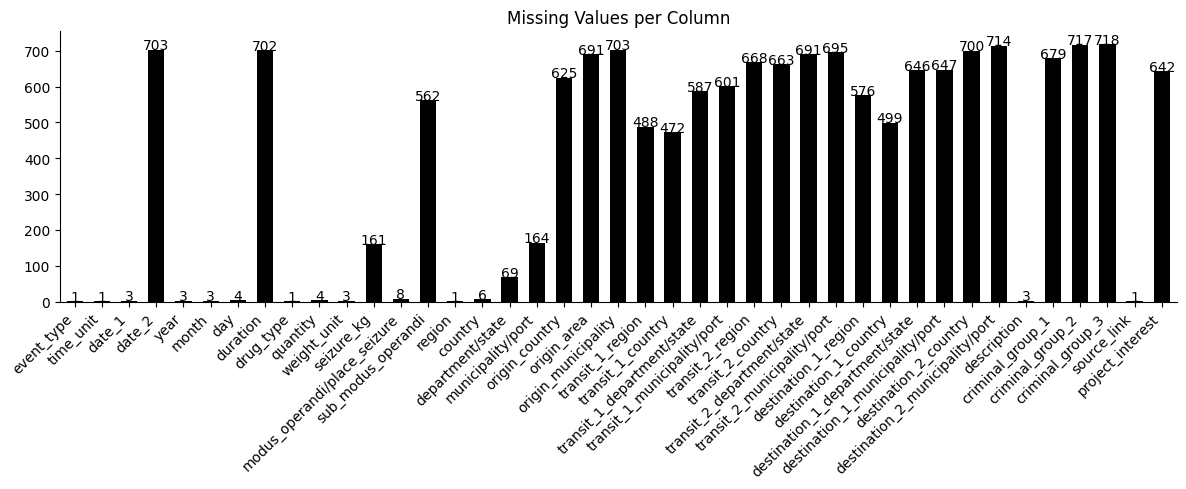

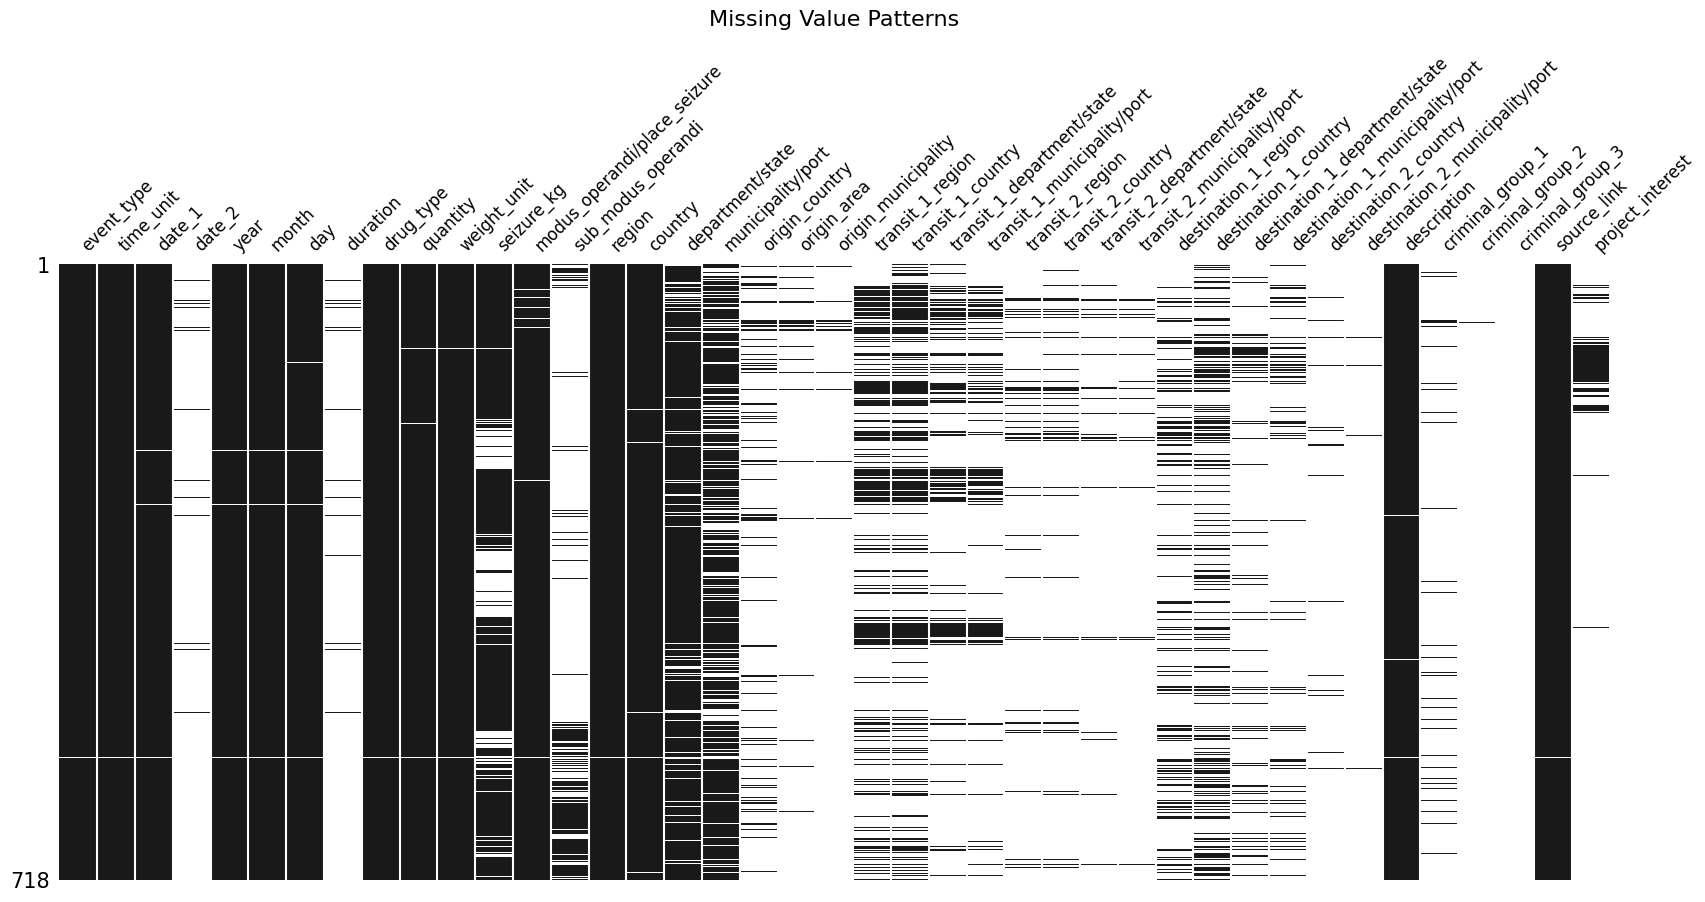

In [62]:

missing_values = df_a_aligned.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")

# Visualization 1: Bar Chart
plt.figure(figsize=(12, 5))
ax = missing_values.plot(kind='bar', color="#000000", width=0.6)
ax.grid(False)
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height()+1, 
            f'{int(i.get_height())}', 
            ha='center', fontsize=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.title("Missing Values per Column")
plt.tight_layout()
plt.show()

# Visualization 2: Missingno Matrix
msno.matrix(
    df_a_aligned,
    figsize=(20, 8),
    color=(0.1, 0.1, 0.1),
    sparkline=False,
    fontsize=12,
    labels=True
)
plt.title("Missing Value Patterns", fontsize=16, pad=20)
plt.show()

##### Key Variables

###### Monthly seizures

/tmp/ipykernel_3836/2295877668.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_3836/2295877668.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_3836/2295877668.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_3836/2295877668.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_3836/2295877668.py:60: FutureWarning: DataFrame.applymap 

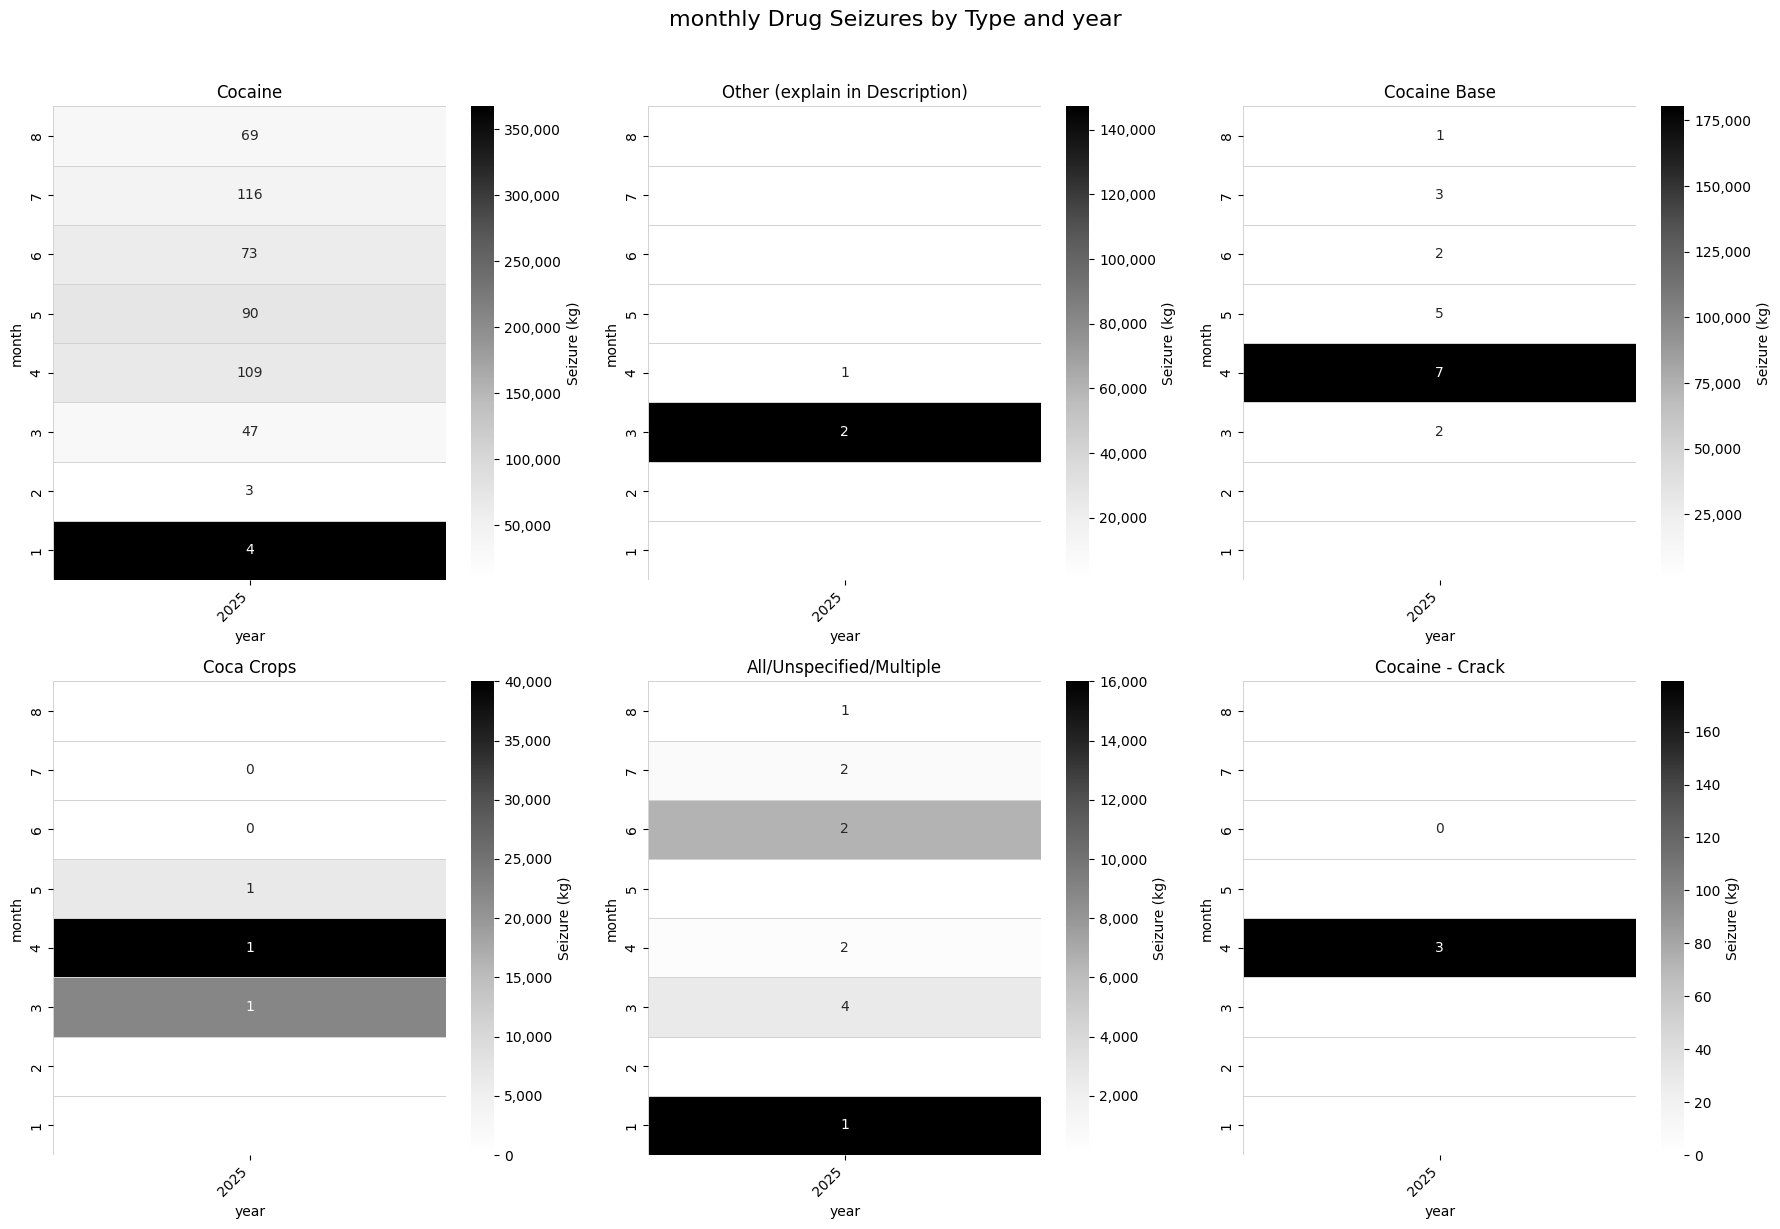

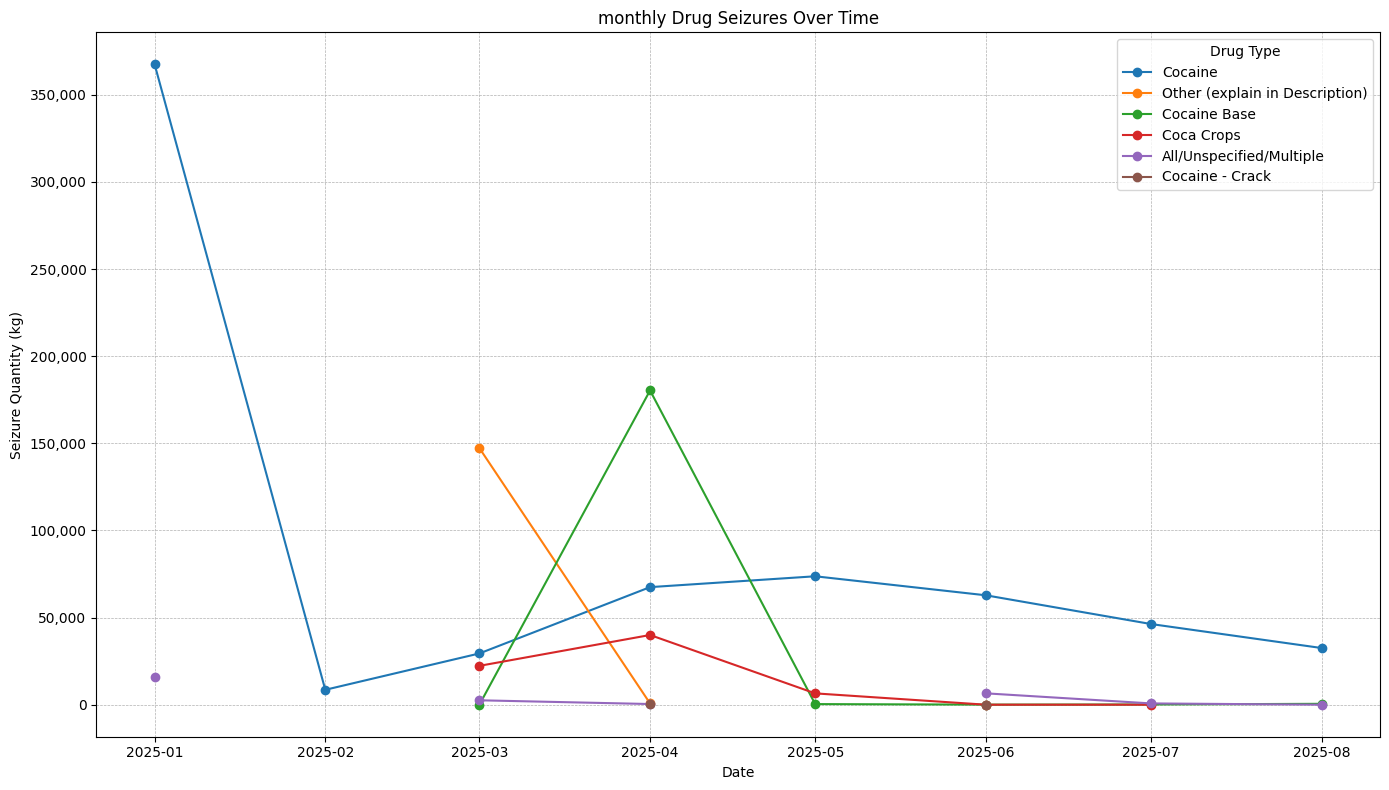

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.ticker import FuncFormatter

# Clean the data - remove rows where drug_type is None/NaN
df_a_aligned = df_a_aligned.dropna(subset=['drug_type'])

# Convert and clean seizure data
df_a_aligned['seizure_kg'] = pd.to_numeric(df_a_aligned['seizure_kg'], errors='coerce')

# Create pivot tables grouped by drug_type
pivot_data = df_a_aligned.groupby(['year', 'month', 'drug_type']).agg(
    seizure_kg=('seizure_kg', 'sum'),
    event_count=('seizure_kg', 'count')
).unstack(level=[0, 2])  # Unstack both year and drug_type

# Extract components
seizure_kg = pivot_data['seizure_kg']
event_counts = pivot_data['event_count']

# Fill NaN values with 0
seizure_kg_filled = seizure_kg.fillna(0)

# Get unique drug types for plotting
drug_types = df_a_aligned['drug_type'].unique()

# Calculate grid dimensions
n_drugs = len(drug_types)
n_cols = 3  # You can adjust this based on your preference
n_rows = math.ceil(n_drugs / n_cols)

# Create figure for grid layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
fig.suptitle("monthly Drug Seizures by Type and year", y=1.02, fontsize=16)

# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Function to format numbers with commas
def format_with_commas(x, pos):
    return f"{x:,.0f}"

# Create formatter
comma_formatter = FuncFormatter(format_with_commas)

# Plot heatmap for each drug type in the grid
for i, drug in enumerate(drug_types):
    ax = axes[i]
    
    # Filter data for current drug type
    drug_kg = seizure_kg.xs(drug, level=1, axis=1)
    drug_counts = event_counts.xs(drug, level=1, axis=1)
    
    # Create annotation text with commas
    annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
    
    heatmap = sns.heatmap(
        drug_kg.sort_index(ascending=False),
        cmap="Greys",
        annot=annot_text,
        fmt='',  # Empty string since we pre-formatted
        cbar_kws={'label': f'Seizure (kg)', 'format': comma_formatter},
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax
    )
    
    # Format colorbar ticks with commas
    if heatmap.collections[0].colorbar is not None:
        heatmap.collections[0].colorbar.ax.yaxis.set_major_formatter(comma_formatter)
    
    ax.set_title(drug)
    ax.set_ylabel("month")
    ax.set_xlabel("year")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Line graph version with comma formatting
plt.figure(figsize=(14,8))

# Create date column for proper time series plotting
df_a_aligned['date'] = pd.to_datetime(df_a_aligned['year'].astype(str) + '-' + df_a_aligned['month'] + '-01')

# Group by date and drug type
line_data = df_a_aligned.groupby(['date', 'drug_type'])['seizure_kg'].sum().unstack()

# Plot each drug type
for drug in drug_types:
    if drug in line_data.columns:
        plt.plot(line_data.index, line_data[drug], marker='o', label=drug)

plt.title("monthly Drug Seizures Over Time")
plt.ylabel("Seizure Quantity (kg)")
plt.xlabel("Date")
plt.legend(title="Drug Type")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_with_commas))

plt.tight_layout()
plt.show()


###### Routes

In [65]:
df_a_aligned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 717 entries, 0 to 717
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   event_type                       717 non-null    object        
 1   time_unit                        717 non-null    object        
 2   date_1                           715 non-null    object        
 3   date_2                           15 non-null     object        
 4   year                             715 non-null    object        
 5   month                            715 non-null    object        
 6   day                              714 non-null    object        
 7   duration                         16 non-null     object        
 8   drug_type                        717 non-null    object        
 9   quantity                         714 non-null    object        
 10  weight_unit                      715 non-null    object        
 11

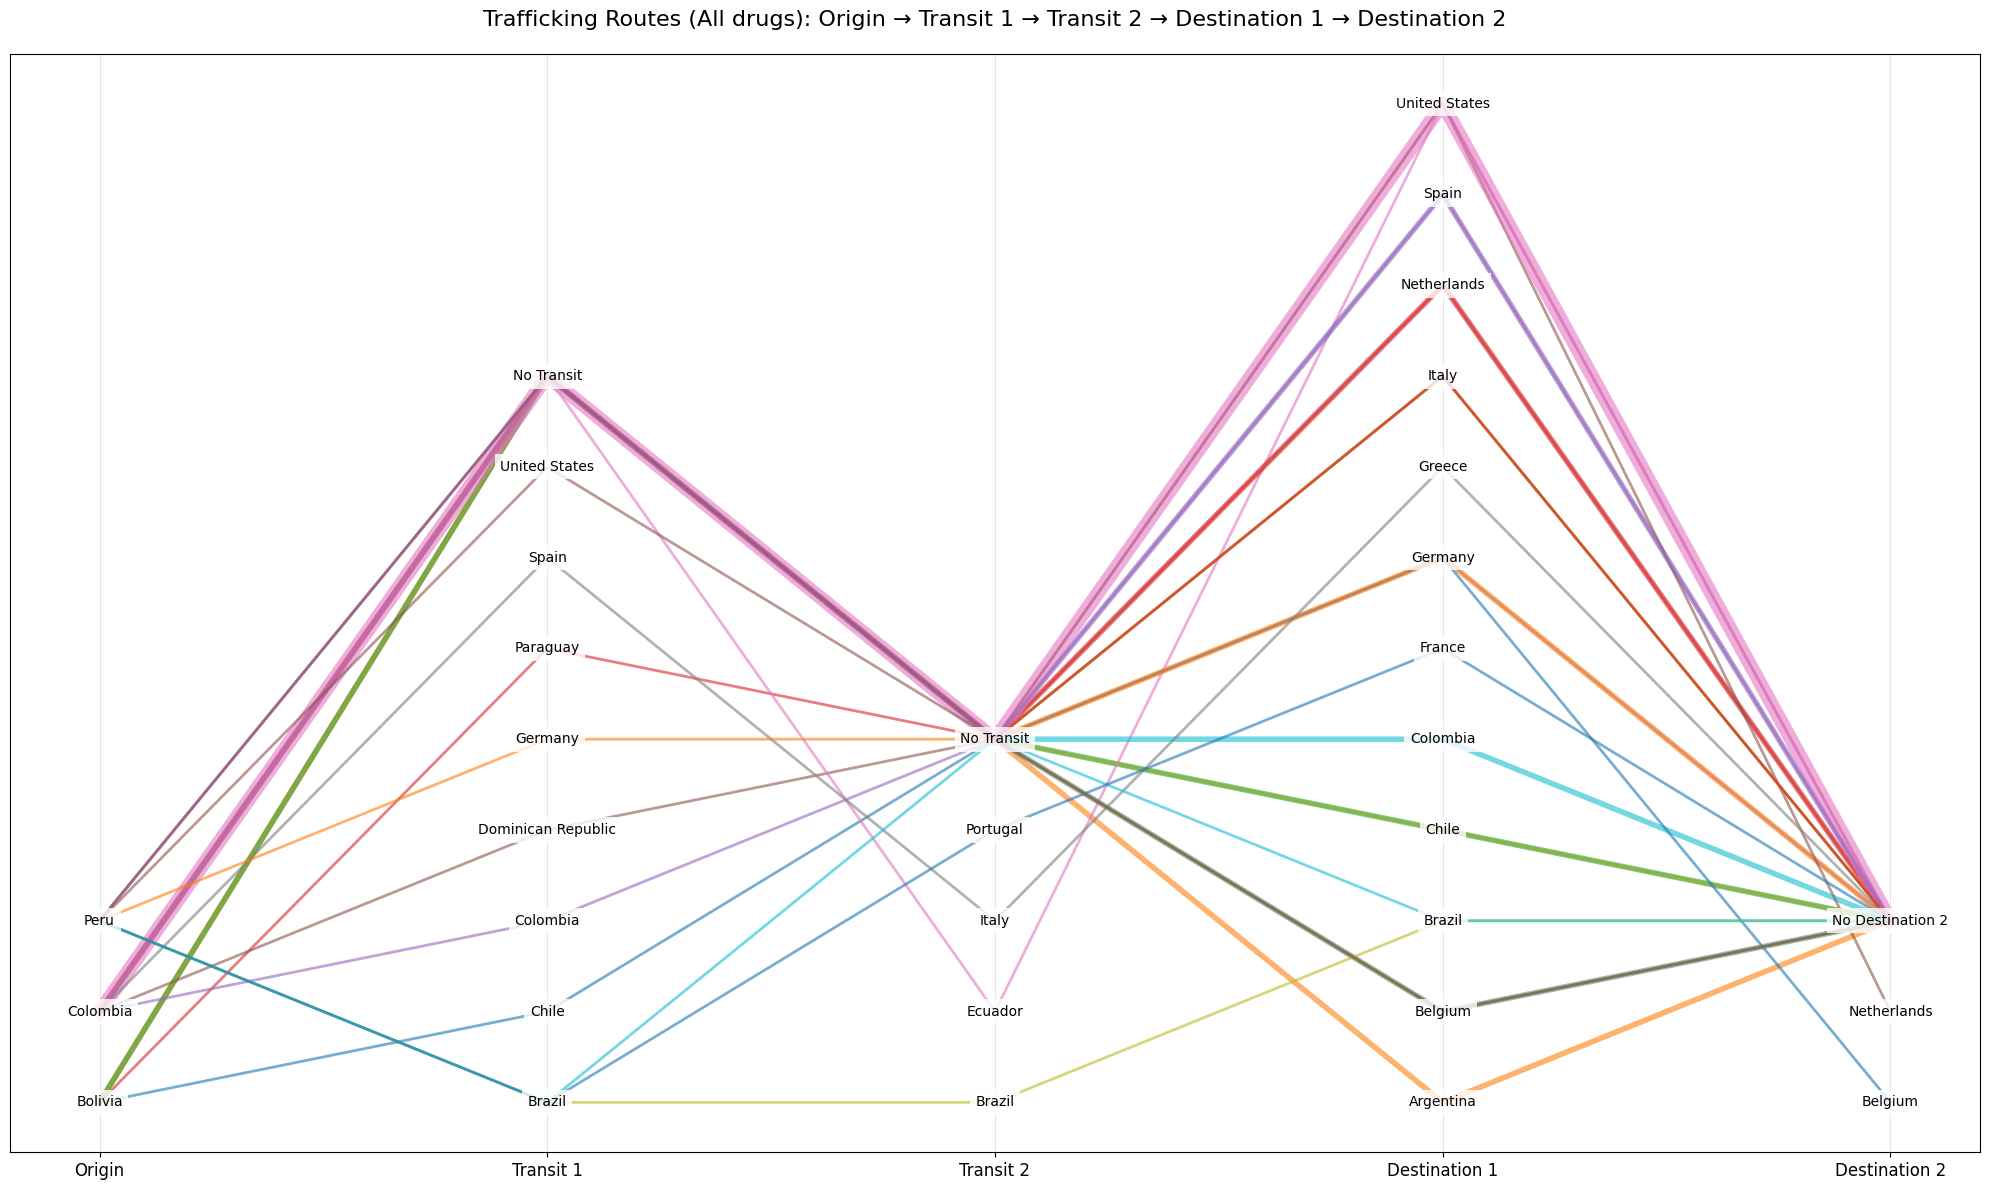

In [66]:
import matplotlib.pyplot as plt

def plot_parallel_sets(df): 
    # Define the column names
    columns = ['origin_country', 'transit_1_country', 'transit_2_country', 
         'destination_1_country', 'destination_2_country']
    
    # Copy and fill missing values
    df = df[columns].copy()
    df[columns[1]] = df[columns[1]].fillna('No Transit')
    df[columns[2]] = df[columns[2]].fillna('No Transit')
    df[columns[4]] = df[columns[4]].fillna('No Destination 2')
    
    # Filter incomplete rows
    df.dropna(subset=[columns[0], columns[3]], inplace=True)
    if df.empty:
        print("Warning: No data with both origin and destination information")
        return
    
    # Count path frequencies
    path_counts = df.groupby(columns).size().reset_index(name='count')
    
    # Prepare the plot
    plt.figure(figsize=(20, 12))

    # Map each category to a y-position (starting at 1)
    categories = {}
    for col in columns:
        values = df[col].unique()
        sorted_vals = sorted([v for v in values if "No" not in v]) + sorted([v for v in values if "No" in v])
        categories[col] = {val: idx + 1 for idx, val in enumerate(sorted_vals)}
    
    # Plot each path
    for _, row in path_counts.iterrows():
        y_values = [categories[col][row[col]] for col in columns]
        plt.plot(range(len(columns)), y_values, linewidth=row['count'] * 2, alpha=0.6)

    # X-axis: step names
    plt.xticks(range(len(columns)), ['Origin', 'Transit 1', 'Transit 2', 'Destination 1', 'Destination 2'], fontsize=12)
    
    # Y-axis: remove default numbers
    plt.yticks([])
    
    # Add node labels
    for i, col in enumerate(columns):
        for val, y in categories[col].items():
            plt.text(i, y, val, ha='center', va='center',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=10)
    
    # Final touches
    plt.title("Trafficking Routes (All drugs): Origin → Transit 1 → Transit 2 → Destination 1 → Destination 2", 
              fontsize=16, pad=20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_parallel_sets(df)

###### Modus operandi

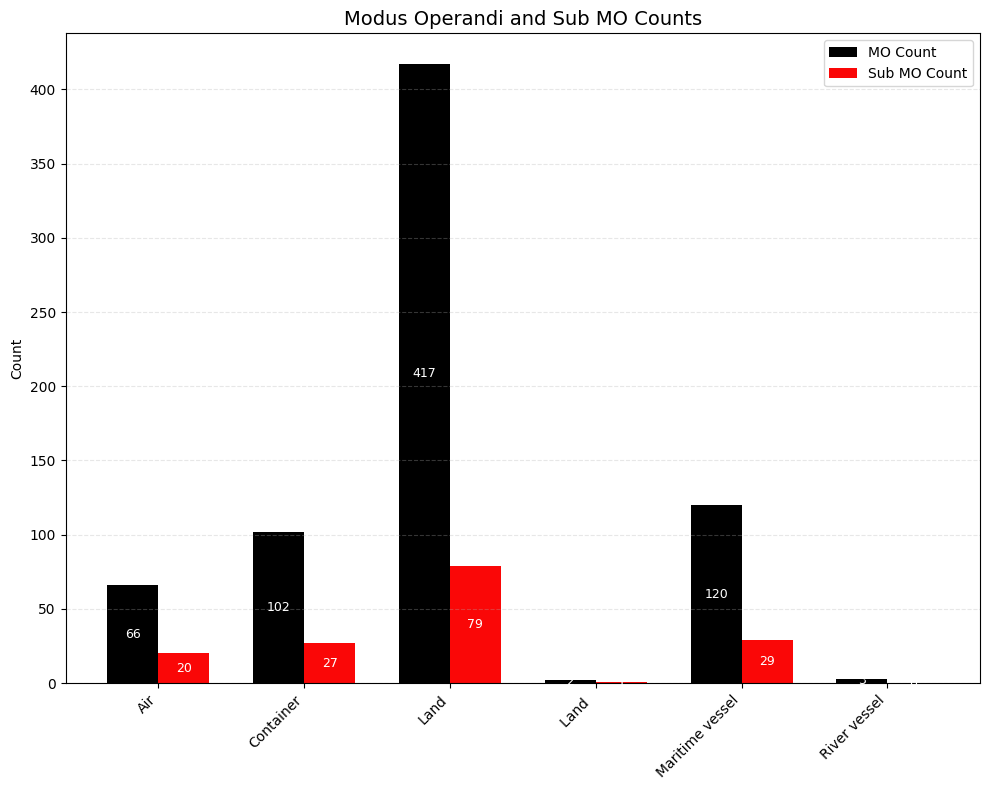

In [67]:
import numpy as np

# Group counts
mo = df_a_aligned_a_aligned['modus_operandi/place_seizure'].value_counts().sort_index()
sub_mo = df_a_aligned_a_aligned.groupby('modus_operandi/place_seizure')['sub_modus_operandi'].count().reindex(mo.index)

# Plot
labels = mo.index
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 8))
b1 = ax.bar(x - w/2, mo, w, label='MO Count', color="#000000")
b2 = ax.bar(x + w/2, sub_mo, w, label='Sub MO Count', color="#FA0707")

# Label bars
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                str(int(bar.get_height())), ha='center', va='center', color='white', fontsize=9)

# Style
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('Modus Operandi and Sub MO Counts', fontsize=14)
ax.legend()
ax.set_ylabel('Count')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()



## Validation

### Theme mapping

In [68]:
category_mapping = {
    "🟥 Event Metadata": [
        "event_type", "time_unit", "date_1", "date_2", "year", "month", "day",
        "duration", "description", "source_link", "project_interest"
    ],
    "🟦 Drugs & Quantities": [
        "drug_type", "quantity", "weight_unit", "seizure_kg"
    ],
    "🟨 Modus Operandi": [
        "modus_operandi/place_seizure", "sub_modus_operandi"
    ],
    "🟩 Seizure Location": [
        "region", "country", "department/state", "municipality/port"
    ],
    "🟫 Origin": [
        "origin_country", "origin_area", "origin_municipality"
    ],
    "🟪 Transit": [
        "transit_1_region", "transit_1_country", "transit_1_department/state", "transit_1_municipality/port",
        "transit_2_region", "transit_2_country", "transit_2_department/state", "transit_2_municipality/port"
    ],
    "🟧 Destination": [
        "destination_1_region", "destination_1_country", "destination_1_department/state",
        "destination_1_municipality/port", "destination_2_country", "destination_2_municipality/port"
    ],
    "⬛ Criminal Actors": [
        "criminal_group_1", "criminal_group_2", "criminal_group_3"
    ]
}

In [70]:
def print_full_mapping(df_a_aligned):

    # Create column index mapping
    column_indices = {col: idx for idx, col in enumerate(df_a_aligned.columns)}

    # Print header
    print("="*80)
    print("COLUMN MAPPING WITH CATEGORIES AND INDICES".center(80))
    print("="*80)
    print(f"Total columns in DataFrame: {len(df_a_aligned.columns)}")
    print(f"Total categories: {len(category_mapping)}\n")

    # Print each category with its columns
    for category, columns in category_mapping.items():
        print(f"\n{category.upper()} (Columns: {len(columns)})")
        print("-"*60)
        
        for col in columns:
            idx = column_indices.get(col, "MISSING")
            non_null = df_a_aligned[col].count() if col in df_a_aligned.columns else 0
            dtype = df_a_aligned[col].dtype if col in df_a_aligned.columns else "N/A"
            
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print any unmapped columns
    mapped_cols = set().union(*category_mapping.values())
    unmapped_cols = set(df_a_aligned.columns) - mapped_cols
    
    if unmapped_cols:
        print("\n⚠️ UNMAPPED COLUMNS:")
        print("-"*60)
        for col in unmapped_cols:
            idx = column_indices[col]
            non_null = df_a_aligned[col].count()
            dtype = df_a_aligned[col].dtype
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print verification summary
    print("\n" + "="*80)
    print("VERIFICATION SUMMARY:")
    print(f"- Mapped columns: {len(mapped_cols & set(df_a_aligned.columns))}")
    print(f"- Unmapped columns: {len(unmapped_cols)}")
    print(f"- Missing expected columns: {len(set(mapped_cols) - set(df_a_aligned.columns))}")
    print("="*80)

# Usage
if __name__ == "__main__":
    print_full_mapping(df_a_aligned)

                   COLUMN MAPPING WITH CATEGORIES AND INDICES                   
Total columns in DataFrame: 42
Total categories: 8


🟥 EVENT METADATA (Columns: 11)
------------------------------------------------------------
   0 | event_type                          | object     | Non-null:  717
   1 | time_unit                           | object     | Non-null:  717
   2 | date_1                              | object     | Non-null:  715
   3 | date_2                              | object     | Non-null:   15
   4 | year                                | object     | Non-null:  715
   5 | month                               | object     | Non-null:  715
   6 | day                                 | object     | Non-null:  714
   7 | duration                            | object     | Non-null:   16
  35 | description                         | object     | Non-null:  715
  39 | source_link                         | object     | Non-null:  717
  40 | project_interest                    |

#### Event Metadata

Variables: _Type, Time unit, Date, Date 2, Year, Month, Day, Duration, Description, Source link, Project interested_

In [71]:
print(category_mapping["🟥 Event Metadata"])

['event_type', 'time_unit', 'date_1', 'date_2', 'year', 'month', 'day', 'duration', 'description', 'source_link', 'project_interest']


In [73]:
def event_metadata_report(df_a_aligned):
    
    
    EVENT_COLS = category_mapping["🟥 Event Metadata"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions
    def to_excel_rows(indices):
        return [i+2 for i in indices]

    def register_issue(name, problematic_df_a_aligned, description):
        nonlocal total_problems
        issue_rows = problematic_df_a_aligned.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_a_aligned,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Check for missing critical columns
    missing_cols = [col for col in EVENT_COLS if col not in df_a_aligned.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Date validations
    date_issues = []
    if 'date_1' in df_a_aligned.columns:
        empty_dates = df_a_aligned[df_a_aligned['date_1'].isna()]
        if not empty_dates.empty:
            count = register_issue(
                'empty_primary_dates',
                empty_dates,
                "Rows missing primary date (date_1)"
            )
            date_issues.append(f"{count} empty date_1 values")

    # Validation 3: Duration consistency
    if all(col in df_a_aligned.columns for col in ['date_2', 'duration']):
        invalid_duration = df_a_aligned[
            (df_a_aligned['date_2'].isna()) & 
            (df_a_aligned['duration'].notna())
        ]
        if not invalid_duration.empty:
            count = register_issue(
                'duration_without_end_date',
                invalid_duration[['date_1', 'date_2', 'duration']],
                "Has duration but no end date (date_2)"
            )
            date_issues.append(f"{count} duration/date_2 mismatches")

    if date_issues:
        report.append(("Date Issues", "; ".join(date_issues)))

    # Validation 4: Time unit logic
    if 'time_unit' in df_a_aligned.columns:
        time_unit_issues = []
        
        # Case 1: Multi-day events marked as individual
        if 'date_2' in df_a_aligned.columns:
            invalid_time = df_a_aligned[
                (df_a_aligned['date_2'].notna()) & 
                (df_a_aligned['time_unit'] == 'Individual')
            ]
            if not invalid_time.empty:
                count = register_issue(
                    'multiday_individual_events',
                    invalid_time[['time_unit', 'date_1', 'date_2']],
                    "Multi-day event marked as 'Individual' time unit"
                )
                time_unit_issues.append(f"{count} multi-day as Individual")

        # Case 2: Individual events with duration
        if 'duration' in df_a_aligned.columns:
            invalid_duration = df_a_aligned[
                (df_a_aligned['time_unit'] == 'Individual') & 
                (df_a_aligned['duration'].notna())
            ]
            if not invalid_duration.empty:
                count = register_issue(
                    'individual_with_duration',
                    invalid_duration[['time_unit', 'duration']],
                    "Individual events shouldn't have duration"
                )
                time_unit_issues.append(f"{count} Individual with duration")

        if time_unit_issues:
            report.append(("Time Unit Issues", "; ".join(time_unit_issues)))

    # Report
    print("="*80)
    print(f"EVENT METADATA VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }

# Usage
validation_results = event_metadata_report(df_a_aligned)

                        EVENT METADATA VALIDATION REPORT                        
                             Total Issues Found: 7                              

SUMMARY CHECKS:
• Date Issues          2 empty date_1 values; 1 duration/date_2 mismatches
• Time Unit Issues     2 multi-day as Individual; 2 Individual with duration

                                DETAILED ISSUES                                 

❗ ROWS MISSING PRIMARY DATE (DATE_1)
   Rows affected: 2 (Spreadsheet rows: [219, 282])

Sample Data:
event_type  time_unit date_1 date_2 year month  day duration drug_type quantity weight_unit  seizure_kg modus_operandi/place_seizure sub_modus_operandi        region  country department/state municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country transit_2_department/state transit_2_municipality/port destination_1_region destination_1_country dest

In [75]:
def highlight_category_cells(sheet_service, spreadsheet_id, sheet_name, validation_results, category_name):
    
    if not validation_results['issues']:
        print("No issues found to highlight")
        return

    # Color: light red
    light_red = {"red": 0.96, "green": 0.8, "blue": 0.8}

    try:
        # Get sheet ID and column positions
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title),data(rowData,startRow,startColumn))"
        ).execute()
        
        sheet_id = None
        col_indices = {}
        
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                headers = sheet['data'][0]['rowData'][0]['values']
                col_indices = {
                    header['formattedValue']: idx 
                    for idx, header in enumerate(headers) 
                    if header.get('formattedValue') in category_mapping[category_name]
                }
                break
        
        if not sheet_id or not col_indices:
            print(f"Target columns not found in sheet '{sheet_name}'")
            return
        
        # Prepare format requests
        requests = []
        for issue in validation_results['issues'].values():
            for row in issue['excel_rows']:  # 1-based row numbers
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": light_red
                                }
                            },
                            "fields": "userEnteredFormat.backgroundColor"
                        }
                    })
        
        # Execute in batches (Google Sheets API limit: 100 requests per batch)
        for i in range(0, len(requests), 100):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+100]}
            ).execute()
        
        print(f"Highlighted {len(requests)} cells in {len(col_indices)} columns")

    except Exception as e:
        print(f"Error: {str(e)}")

# Usage
highlight_category_cells(
    category_name="🟥 Event Metadata",
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="aligned",
    validation_results=validation_results
)

Highlighted 77 cells in 11 columns


#### Drugs & Quantities

In [76]:
def drugs_and_quantities_report(df_a_aligned):
    
    DRUG_COLS = category_mapping["🟦 Drugs & Quantities"]
    report = []
    issues = {}
    total_problems = 0

    # Helper function
    def to_excel_rows(indices):
        return [i+2 for i in indices]  # Convert pandas index to spreadsheet rows

    def register_issue(name, problematic_df_a_aligned, description):
        nonlocal total_problems
        issue_rows = problematic_df_a_aligned.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_a_aligned,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Check for missing critical columns
    missing_cols = [col for col in DRUG_COLS if col not in df_a_aligned.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Drug type validations
    if 'drug_type' in df_a_aligned.columns:
        invalid_drugs = df_a_aligned[df_a_aligned['drug_type'].isna() | df_a_aligned['drug_type'].str.lower().isin(['', 'unknown', 'n/a', 'na'])]
        if not invalid_drugs.empty:
            count = register_issue(
                'invalid_drug_types',
                invalid_drugs,
                "Missing or invalid drug type values"
            )
            report.append(("Drug Type Issues", f"{count} invalid/missing drug types"))

    # Validation 3: Quantity validations
    if 'quantity' in df_a_aligned.columns:
        # Case 1: Non-numeric quantities
        numeric_qty = pd.to_numeric(df_a_aligned['quantity'], errors='coerce')
        non_numeric = df_a_aligned[numeric_qty.isna()]
        
        # Case 2: Zero/negative quantities
        invalid_values = df_a_aligned[(numeric_qty.notna()) & (numeric_qty <= 0)]
        
        qty_issues = pd.concat([non_numeric, invalid_values]).drop_duplicates()
        if not qty_issues.empty:
            count = register_issue(
                'invalid_quantities',
                qty_issues,
                "Non-numeric or zero/negative quantities"
            )
            report.append(("Quantity Issues", f"{count} invalid quantities"))

    # Validation 4: Weight unit validations
    if 'weight_unit' in df_a_aligned.columns:
        valid_units = dropdown_options.get('weight_unit', [])
        valid_units_lower = [str(u).lower() for u in valid_units]
        
        invalid_units = df_a_aligned[
            ~df_a_aligned['weight_unit'].astype(str).str.lower().isin(valid_units_lower)
            | df_a_aligned['weight_unit'].isna()
        ]
        
        if not invalid_units.empty:
            count = register_issue(
                'invalid_weight_units',
                invalid_units,
                f"Invalid weight units (valid: {', '.join(valid_units)})"
            )
            report.append(("Weight Unit Issues", f"{count} invalid units"))

    # Validation 5: Seizure weight consistency
    if all(col in df_a_aligned.columns for col in ['seizure_kg', 'weight_unit', 'quantity']):
        # Convert to numeric (handling errors)
        seizure_numeric = pd.to_numeric(df_a_aligned['seizure_kg'], errors='coerce')
        qty_numeric = pd.to_numeric(df_a_aligned['quantity'], errors='coerce')
        
        # Case 1: Invalid seizure values
        invalid_seizure = df_a_aligned[seizure_numeric.isna() | (seizure_numeric < 0)]
        
        # Case 2: Kilogram unit mismatch
        kg_mismatch = df_a_aligned[
            (df_a_aligned['weight_unit'].str.lower() == 'kilogram') &
            (qty_numeric.notna()) &
            (seizure_numeric.notna()) &
            (qty_numeric != seizure_numeric)
        ]
        
        seizure_issues = pd.concat([invalid_seizure, kg_mismatch]).drop_duplicates()
        if not seizure_issues.empty:
            count = register_issue(
                'seizure_weight_issues',
                seizure_issues,
                "Invalid seizure weights or kilogram mismatches"
            )
            report.append(("Seizure Weight Issues", f"{count} problems found"))

    # Generate the report
    print("="*80)
    print(f"DRUGS & QUANTITIES VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }

# Usage (identical to Event Metadata report)
validation_results = drugs_and_quantities_report(df_a_aligned)

                      DRUGS & QUANTITIES VALIDATION REPORT                      
                            Total Issues Found: 191                             

SUMMARY CHECKS:
• Quantity Issues      18 invalid quantities
• Weight Unit Issues   2 invalid units
• Seizure Weight Issues 171 problems found

                                DETAILED ISSUES                                 

❗ NON-NUMERIC OR ZERO/NEGATIVE QUANTITIES
   Rows affected: 18 (Spreadsheet rows: [100, 187, 195, 214, 226, 237, 333, 350, 386, 396, 553, 555, 558, 567, 571, 573, 691, 693])

Sample Data:
event_type  time_unit     date_1 date_2 year month day duration drug_type   quantity                    weight_unit  seizure_kg modus_operandi/place_seizure sub_modus_operandi          region            country   department/state  municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country tr

In [78]:
def highlight_drugs_quantities_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
  
    if not validation_results['issues']:
        print("No issues found to highlight in Drugs & Quantities")
        return
    
    highlight_color = {
        "red": 0.8,
        "green": 0.9,
        "blue": 1.0
    }
    
    try:
        # Get sheet metadata and column positions
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title),data(rowData,startRow,startColumn))"
        ).execute()
        
        sheet_id = None
        col_indices = {}
        target_columns = category_mapping["🟦 Drugs & Quantities"]
        
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                headers = sheet['data'][0]['rowData'][0]['values']
                col_indices = {
                    header['formattedValue']: idx 
                    for idx, header in enumerate(headers) 
                    if header.get('formattedValue') in target_columns
                }
                break
        
        if not sheet_id or not col_indices:
            print("Target columns not found in sheet")
            return
        
        # Prepare format requests for all issues
        requests = []
        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # Already 1-based
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": highlight_color
                                }
                            },
                            "fields": "userEnteredFormat.backgroundColor"
                        }
                    })
        
        # Batch execute (Google Sheets API limit: 100 requests per batch)
        batch_size = 50
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()
        
        print(f"✓ Highlighted {len(requests)} cells across {len(col_indices)} Drugs & Quantities columns")

    except Exception as e:
        print(f"Error highlighting Drugs & Quantities cells: {str(e)}")

# Usage
validation_results = drugs_and_quantities_report(df_a_aligned)
highlight_drugs_quantities_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="aligned",
    validation_results=validation_results
)

                      DRUGS & QUANTITIES VALIDATION REPORT                      
                            Total Issues Found: 191                             

SUMMARY CHECKS:
• Quantity Issues      18 invalid quantities
• Weight Unit Issues   2 invalid units
• Seizure Weight Issues 171 problems found

                                DETAILED ISSUES                                 

❗ NON-NUMERIC OR ZERO/NEGATIVE QUANTITIES
   Rows affected: 18 (Spreadsheet rows: [100, 187, 195, 214, 226, 237, 333, 350, 386, 396, 553, 555, 558, 567, 571, 573, 691, 693])

Sample Data:
event_type  time_unit     date_1 date_2 year month day duration drug_type   quantity                    weight_unit  seizure_kg modus_operandi/place_seizure sub_modus_operandi          region            country   department/state  municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country tr

### Modus Operandi 

Variables: Modus Operandi/place of seizure, Sub MO

In [79]:
def modus_operandi_report(df_a_aligned):

    MODUS_COLS = category_mapping["🟨 Modus Operandi"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions (identical to metadata report)
    def to_excel_rows(indices):
        return [i+2 for i in indices]  # For spreadsheet row reference

    def register_issue(name, problematic_df_a_aligned, description):
        nonlocal total_problems
        issue_rows = problematic_df_a_aligned.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_a_aligned[list(set(MODUS_COLS) & set(df_a_aligned.columns))],  # Only show relevant cols
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Missing critical columns
    missing_cols = [col for col in MODUS_COLS if col not in df_a_aligned.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Main Modus Operandi checks
    modus_issues = []
    if 'modus_operandi/place_seizure' in df_a_aligned.columns:
        empty_modus = df_a_aligned[df_a_aligned['modus_operandi/place_seizure'].isna()]
        if not empty_modus.empty:
            count = register_issue(
                'empty_modus_operandi',
                empty_modus,
                "Rows missing modus operandi/place of seizure"
            )
            modus_issues.append(f"{count} empty modus_operandi values")

    # # Validation 3: Sub-Modus validation
    # if 'sub_modus_operandi' in df_a_aligned.columns:
    #     orphaned_sub = df_a_aligned[
    #         df_a_aligned['sub_modus_operandi'].notna() & 
    #         (df_a_aligned['modus_operandi/place_seizure'].isna())
    #     ]
    #     if not orphaned_sub.empty:
    #         count = register_issue(
    #             'orphaned_sub_modus',
    #             orphaned_sub[['modus_operandi/place_seizure', 'sub_modus_operandi']],
    #             "Sub-modus operandi exists without main modus"
    #         )
    #         modus_issues.append(f"{count} orphaned sub-modus cases")

    if modus_issues:
        report.append(("Modus Operandi Issues:", "; ".join(modus_issues)))

    # Generate report structure
    print("="*80)
    print(f"MODUS OPERANDI VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section (identical format)
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings (identical format)
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }
    
# Usage 
validation_results = modus_operandi_report(df_a_aligned)

                        MODUS OPERANDI VALIDATION REPORT                        
                             Total Issues Found: 7                              

SUMMARY CHECKS:
• Modus Operandi Issues: 7 empty modus_operandi values

                                DETAILED ISSUES                                 

❗ ROWS MISSING MODUS OPERANDI/PLACE OF SEIZURE
   Rows affected: 7 (Spreadsheet rows: [31, 33, 41, 52, 65, 76, 254])

Sample Data:
sub_modus_operandi modus_operandi/place_seizure
              <NA>                         <NA>
              <NA>                         <NA>
              <NA>                         <NA>
------------------------------------------------------------

          Note: Spreadsheet rows account for header (pandas index + 2)          


In [80]:
def format_modus_operandi_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
    
    if not validation_results.get('issues'):
        print("No Modus Operandi cells to highlight")
        return
    
    # Light yellow color (matching 🟨 emoji)
    HIGHLIGHT_COLOR = {
        "red": 1.0,
        "green": 1.0,
        "blue": 0.8  # #FFFFCC
    }
    
    try:
        # Get sheet and column mappings
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title),data(rowData,startRow,startColumn))"
        ).execute()
        
        sheet_id = None
        col_indices = {}
        target_columns = category_mapping["🟨 Modus Operandi"]
        
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                headers = sheet['data'][0]['rowData'][0]['values']
                col_indices = {
                    header['formattedValue']: idx 
                    for idx, header in enumerate(headers) 
                    if header.get('formattedValue') in target_columns
                }
                break
        
        if not sheet_id or not col_indices:
            print("Modus Operandi columns not found in sheet")
            return
        
        # Prepare format requests for all issues
        requests = []
        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # Already 1-based
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": HIGHLIGHT_COLOR,
                                    "textFormat": {"bold": True}  # Optional: Match Drugs style
                                }
                            },
                            "fields": "userEnteredFormat(backgroundColor,textFormat)"
                        }
                    })
        
        # Batch execute (100 requests per batch)
        batch_size = 100
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()
        
        print(f"✓ Highlighted {len(requests)} Modus Operandi cells")

    except Exception as e:
        print(f"Error highlighting cells: {str(e)}")

# Usage 
format_modus_operandi_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="aligned",
    validation_results= validation_results
)

✓ Highlighted 14 Modus Operandi cells


## Sync

In [116]:
def add_uid_column(sheet_service, spreadsheet_id, sheet_name, uid_col_name="uid"):
    import uuid

    # Get sheet details and data
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        includeGridData=True
    ).execute()

    sheet_id = None
    row_count = 0
    original_col_count = 0
    
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            row_count = sheet["properties"]["gridProperties"]["rowCount"]
            original_col_count = sheet["properties"]["gridProperties"]["columnCount"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    # Find the last column with data
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:{row_count}",
    ).execute()
    
    values = result.get('values', [])
    last_col_with_data = 0
    
    if values:
        for row in values:
            if len(row) > last_col_with_data:
                last_col_with_data = len(row)
    
    # If no data found, use the original column count
    insert_col_index = last_col_with_data if last_col_with_data > 0 else original_col_count

    # Step 1: Insert a new column after the last column with data
    insert_request = {
        "requests": [
            {
                "insertDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "COLUMNS",
                        "startIndex": insert_col_index,
                        "endIndex": insert_col_index + 1
                    },
                    "inheritFromBefore": False
                }
            }
        ]
    }
    sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=insert_request
    ).execute()

    # Step 2: Write header
    header_request = {
        "requests": [
            {
                "updateCells": {
                    "rows": [
                        {"values": [{"userEnteredValue": {"stringValue": uid_col_name}}]}
                    ],
                    "fields": "userEnteredValue",
                    "start": {"sheetId": sheet_id, "rowIndex": 0, "columnIndex": insert_col_index}
                }
            }
        ]
    }
    sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=header_request
    ).execute()

    # Step 3: Write UUIDs
    values = [[str(uuid.uuid4())] for _ in range(row_count - 1)]
    
    # Convert column index to letter (A=0, B=1, etc.)
    col_letter = chr(65 + insert_col_index) if insert_col_index < 26 else chr(64 + insert_col_index // 26) + chr(65 + insert_col_index % 26)
    range_uid = f"{sheet_name}!{col_letter}2:{col_letter}{row_count}"

    body = {
        "valueInputOption": "RAW",
        "data": [
            {
                "range": range_uid,
                "values": values
            }
        ]
    }

    sheet_service.spreadsheets().values().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=body
    ).execute()

    print(f"Added UID column '{uid_col_name}' to sheet '{sheet_name}' at column {col_letter}")

add_uid_column(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")

Added UID column 'uid' to sheet 'aligned' at column AO


In [117]:
def copy_uid_column_to_last_column(sheet_service, spreadsheet_id, source_sheet_name, target_sheet_name, uid_col_name="uid"):
    """
    Copies the UID column from source sheet to the last written column in target sheet.
    """
    
    # First, get the UID values from source sheet
    source_values = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{source_sheet_name}"
    ).execute()
    
    # Find UID column index in source
    if "values" not in source_values or len(source_values["values"]) == 0:
        raise ValueError(f"No data found in source sheet '{source_sheet_name}'")
    
    source_headers = source_values["values"][0]
    try:
        source_uid_col_index = source_headers.index(uid_col_name)
    except ValueError:
        raise ValueError(f"UID column '{uid_col_name}' not found in source sheet '{source_sheet_name}'")
    
    # Extract UID values (skip header)
    uid_values = []
    if len(source_values["values"]) > 1:
        for row in source_values["values"][1:]:
            if len(row) > source_uid_col_index:
                uid_values.append([row[source_uid_col_index]])
            else:
                uid_values.append([""])  # Empty if no UID in this row
    
    # Get target sheet data to find the last written column
    target_values = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{target_sheet_name}"
    ).execute()
    
    # Find the last column with data in the target sheet
    last_column_index = 0
    if "values" in target_values and len(target_values["values"]) > 0:
        for row in target_values["values"]:
            last_column_index = max(last_column_index, len(row) - 1)
    
    # Convert column index to letter (A=0, B=1, etc.)
    def column_index_to_letter(index):
        if index < 26:
            return chr(65 + index)
        else:
            return chr(64 + index // 26) + chr(65 + index % 26)
    
    target_col_letter = column_index_to_letter(last_column_index + 1)
    
    # Write header to the next empty column
    header_range = f"{target_sheet_name}!{target_col_letter}1"
    header_body = {
        "values": [[uid_col_name]]
    }
    sheet_service.spreadsheets().values().update(
        spreadsheetId=spreadsheet_id,
        range=header_range,
        valueInputOption="RAW",
        body=header_body
    ).execute()
    
    # Write UID values to the same column
    if uid_values:
        start_row = 2  # Start from row 2 (after header)
        end_row = start_row + len(uid_values) - 1
        
        uid_range = f"{target_sheet_name}!{target_col_letter}{start_row}:{target_col_letter}{end_row}"
        
        body = {
            "values": uid_values
        }
        
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=uid_range,
            valueInputOption="RAW",
            body=body
        ).execute()
    
    print(f"Successfully copied {len(uid_values)} UID values from '{source_sheet_name}' to column {target_col_letter} in '{target_sheet_name}'")
    return len(uid_values)

# Usage:
copy_uid_column_to_last_column(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned", "db-test")

Successfully copied 786 UID values from 'aligned' to column AQ in 'db-test'


786

## db-test revalidation

## Progress

### batch 1
 
✔ Last modified by and at (obvious in the sheet, just automated here for reports)

✔ Standard column names

✔ Dropdowns: Corrections & "Official" list of places added to due cols (country-level)

✔ Event Metadata validation complete: rules and report 

✔ Highlights: after validation report it colors problematic rows in red 


### b.2

✔ Workflow

✔ Drugs & Quantities basic validation complete: rules and report

✔ Highlights: after validation report it colors problematic rows in blue 

✔ Reports now all include total number of problems per thematic area



### b.3

✔ Drugs & Quantities pt 2: last rule

✔ Conversion system: actual weight units to metric tons (new column)

✔ Number formats applied: decimals and commas to numeric quantities (US standard)

✔ bugs solved: code is still sensitive to formatting in the original google sheet (col names, dropdowns, some data types)

✔ Started provenance analysis

-> Convergent issues: for now we can use dif colors, but when presenting...it is simpler with 1 color & reports 

-> Logic: corrections by investigators not shown until next revision

### b.4
✔ Validation Report & Highlights: Modus Operandi/place of seizure, Sub MO 

-> pero, a medida que avanzamos en la validación aparecen convergent issues (se superponen colores, los reportes están OK)

    -> proposals:
    
    * aplicar formatos en el original y corregir lo más pronto 
    
    * oportunidad de mejora (using what we already have): 

| transport_method | transport_vehicle    | transport_presentation  | transport_concealment      |
|------------------|----------------------|-------------------------|---------------------------|
| River            | Yola                 | Pressed bricks          | False compartments        |
| Air              | Commercial flight    | Powder in plastic bags  | Hidden in luggage         |
| Land             | Truck                | Cocaine paste barrels   | Mixed with legal goods    |
| Body Carrier     | Pedestrian           | Capsules                | Ingested                  |


### b.5 

- Code refactoring, theme mapping

- New highlights & reports


### Next

- Seizure Location (Region, Country, Department/State, Municipality/Port)

### Pending 

- Finish Drugs & Quantities: refine conversion, what to do with other the varieties in weight units?

- db-test team verifications

- Protected ranges